<div style="text-align: center; padding: 30px 10px;">

<h2 style="font-size: 30px; margin-top: 5px;">
Лабораторная работа 4. Numpy. Pandas. Графики.
</h2>

<hr style="width: 60%; border: 1px solid #10069f; margin: 25px auto;">

</div>

Если Вы видите <b><font color="#FF69B4"> Ваш ответ здесь </font></b> - надо поменять текст внутри блока на свой текстовый ответ на вопрос.


ВАЖНО! Здесь и далее от вас ожидается чистый код, близкий к тому, что нужно в индустрии. В контексте данной лабораторной работы ожидаются корректные названия у полей, методов и переменных, которые вы вводите; корректная инкапсуляция - нижнее подчеркивание или два перед названием метода или атрибута. Для корректной инкапсуляции можно (и даже нужно) добавлять нижние подчеркивания даже к названиям методов/атрибутов из условий задач :)

## 1. О джунглях и матрицах (1.5 балла)

### 1.1 Создание матриц (0.25 балла)

Создайте 4 матрицы
- A - "шахматную" из нулей и единиц, размера 6 на 3, левое верхнее значение (A[0][0]) равно 1,
- В - из чисел от 1 до 24, записанных в виде змейки, размера 6 на 4,
- C - из случайных целых чисел от 2 до 10 (обе границы включительно), размера 4 на 3
- D - из нулей с единичками на главной диагонали, размера 4 на 4.

**Создайте из этих матриц "лоскутную" матрицу S**

A В

С D

используя **только стандартные** операции numpy. Comprehensions использовать нельзя.

После этого допишите к полученной матрице S матрицу F размера 10 на 2 из нулей, чтобы получилась матрица G:

S F

P.S. Когда мы говорим, что матрица имеет размер x на y, x - количество строк, y - количество столбцов.

In [1]:
import numpy as np

A = np.fromfunction(lambda i, j: (i + j) % 2 == 0, (6, 3), dtype=int)
B = np.arange(1, 25).reshape(6, 4)
B[1::2, :] = B[1::2, ::-1]
C = np.random.randint(2, 11, size=(4, 3))
D = np.eye(4, dtype=int)

S = np.block([[A, B], [C, D]])

F = np.zeros((10, 2), dtype=int)

G = np.block([[S, F]])

### 1.2 Джунгли зовут! (0.25 балла)

Перед вами матрица M - карта местности тяжелопроходимых джунглей, составленная Ларой Крофт. На карте каждая ячейка - целое число, обозначающее высоту над уровнем моря (если число больше нуля) в метрах или глубину моря (если число меньше нуля) в метрах в данной ячейке карты размером метр на метр. Если число 0, то это часть суши - берег.


Вам необходимо посчитать:
- Общую площадь клеточек моря, в которых его глубина больше 5 (в м^2)
- Общий объём всей воды на карте (в м^3)
- Максимальную высоту над уровнем моря, которая есть на этой карте (в м)

In [2]:
def find_deep_sea_area(M):
    return np.sum(M < -5)

def find_water_volume(M):
    return np.sum(-M[M < 0])

def find_max_height(M):
    q = M[M > 0]
    if q.size == 0:
        return 0
    return np.max(q)

In [3]:
# Можно подставить свой пример
M = np.array([
    [-7, -3, -1, 0],
    [-4, -3, 1, 19],
    [-2, 0, 4, 25],
    [-1, 3, 6, 9]
])

# простая проверка для примера выше
assert np.isclose(find_deep_sea_area(M), 1)
assert np.isclose(find_water_volume(M), 21)
assert np.isclose(find_max_height(M), 25)

print("Общая площадь моря глубиной более 5м на карте -", find_deep_sea_area(M), "м^2")
print("Общий объем воды на карте -", find_water_volume(M), "м^3")
print("Максимальный уровень над уровнем моря на карте -", find_max_height(M), "м")

Общая площадь моря глубиной более 5м на карте - 1 м^2
Общий объем воды на карте - 21 м^3
Максимальный уровень над уровнем моря на карте - 25 м


### 1.3 Функция проверки (0.5 балла)

На вход функции поступает произвольное (>2) кортежей размеров (shape) различных матриц. Необходимо вернуть True если можно последовательно сложить эти матрицы (возможно, с помощью broadcasting), и False если нет.

In [4]:
def check_successful_broadcast(*matrices):
    ans = matrices[0]
    for matrix in matrices[1:]:
        difference = len(ans) - len(matrix)
        if difference > 0:
            matrix = (1,) * difference + matrix
        else:
            ans = (1,) * (-difference) + ans
        for d1, d2 in zip(ans, matrix):
            if d1 != d2 and d1 != 1 and d2 != 1:
                return False
        ans = tuple(max(d1, d2) for d1, d2 in zip(ans, matrix))
    return True

In [5]:
assert check_successful_broadcast((5, 6, 7), (6, 7), (1, 7))
assert check_successful_broadcast((2,1), (1,3), (2,4)) == False

### 1.4 Попарные расстояния (0.5 балла)

На вход подаются матрицы A размера m x k и матрица B размера n x k. Нужно получить матрицу размера m x n, содержащую попарные евклидовы расстояния.

Можно пользоваться только базовыми функциями, нельзя пользоваться циклами, сторонними библиотеками; скорее всего, пригодится broadcasting. Авторское решение записывается **в одну строчку** в соответствии со всеми правилами кодстайла.

In [6]:
def pairwise_distances(A, B):
    return np.sqrt(np.sum(A ** 2, axis=1, keepdims=True) + np.sum(B ** 2, axis=1) - 2 * A @ B.T)

In [7]:
A = np.array([[0, 0], [1, 0]])
B = np.array([[0, 1], [1, 1]])

correct = np.array([[1, np.sqrt(2)], [np.sqrt(2), 1]])

result = pairwise_distances(A, B)

assert np.allclose(result, correct)

Объясни принцип работы этой одной строчки. Что именно происходит в ней?

<b><font color="red">
Ответ:

Пусть a, b - вектора 1*k \n

dist(a, b) = np.sqrt(np.sum((a - b) ** 2)) = np.sqrt(np.sum(a ** 2) + np.sum(b ** 2) - 2 * np.sum(a @ b.T))

Затем, для матриц A и B нужно учитывать размерности:

np.sum(A**2, axis=1, keepdims=True) - вектор-столбец сумм квадратов элементов строк A, форма (m, 1).

Без keepdims=True форма была бы (m,), что потом при broadcasting неверно получится итоговая размерность итоговой матрицы.

np.sum(B**2, axis=1) - вектор-строка сумм квадратов строк B, форма (n,).

Их сумма - то что надо, формы (m, 1) + (n,) = (m, 1) + (1, n) = (m, n).

A @ B.T - матрица скалярных произведений строк A и B, форма (m, n).

# 2. О скитаниях вечных и о Palomar1 (2 балла)

Palomar 1 — шаровое скопление, входящее в группу Паломар в созвездии Цефея, расположенное, возможно, во внешнем рукаве галактики Млечный Путь. Обнаружено Джорджем О. Абеллом в 1954 году на снимках Palomar Survey Sky, его каталогизировали как **шаровое скопление**. **Шаровое звёздное скопление** — звёздное скопление, содержащее большое число звёзд, тесно связанное гравитацией и обращающееся вокруг галактического центра в качестве спутника.

Возраст скопления - от 6,3 до 8 млрд лет, что делает его очень молодым по сравнению с другими шаровыми скоплениями Млечного Пути.

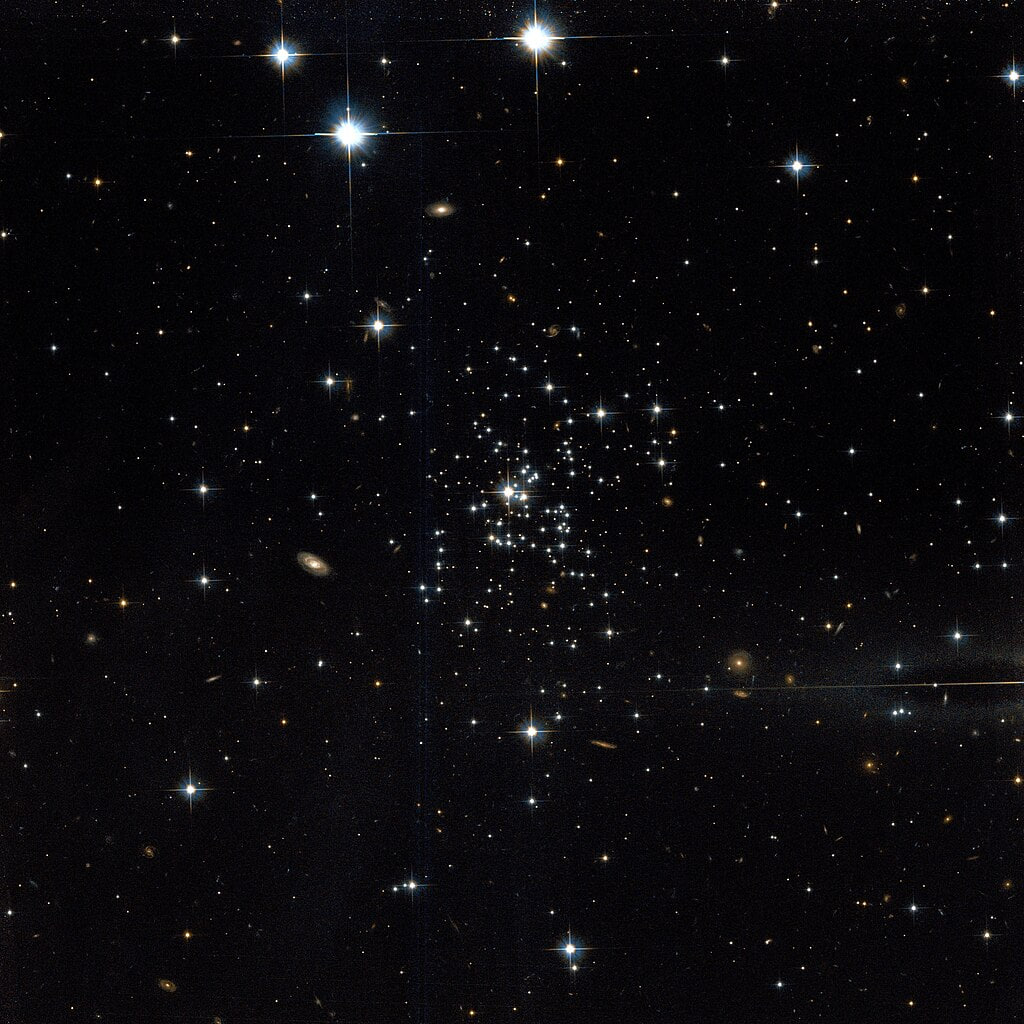

**ВАЖНО!!!**

Требования к графикам в данной главе:

- Должны быть выполнены при помощи matplotlib
- Фон цвета #519dfc с непрозрачностью 15%
- Должна быть сетка
- Должны быть название (на русском языке), подписаны оси (на русском, с размерностями, если надо), на осях должны быть отметки
- В наборе данных довольно много точек. Выбирайте столько точек, чтобы график был читаемым; зачастую если оставить все, график не будет информативным.

## 2.1 Орбита на плоскости (X; Y) (0.5 балла)

В файле Pal1.dat приведены расчётные положения и скорости шарового скопления Palomar1 в декартовой галактоцентрической системе координат, начиная c текущего момента. Заголовки столбцов отсутствуют. Структура файла показана в таблице (данные округлены):

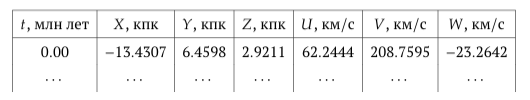

Загрузите данные из файла и постройте график координат Palomar1 на оси (X; Y).

Цвет точек должен варьироваться в зависимости от парамера t; также надо отдельно нарисовать другим цветом начальную точку и тем же цветом нарисовать вектор скорости из неё (в какую сторону движется галактика)

Градиент из легенды вынести справа от графика.

1


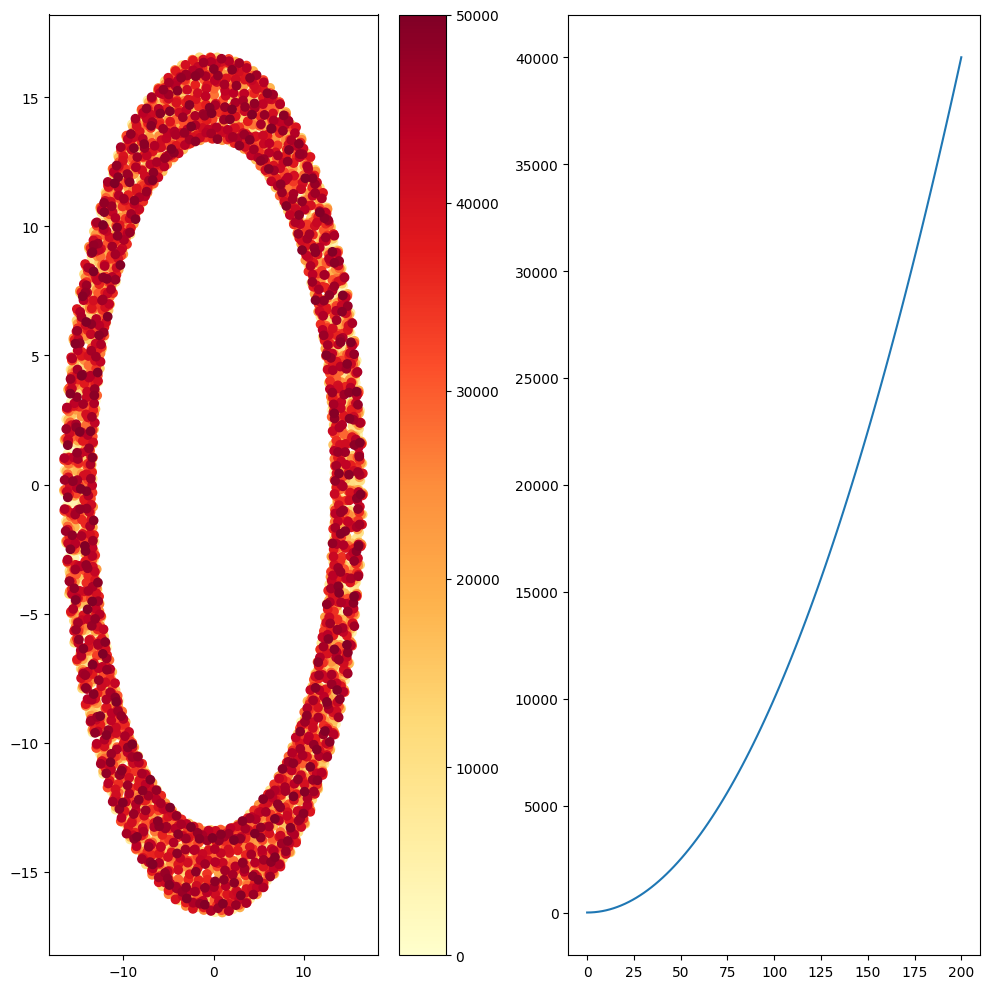

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Pal1.dat", sep=' ')[::10]

fig, ax = plt.subplots(1, 2, figsize=(10, 10))
print(fig.number)
sc = ax[0].scatter(df['X'], df['Y'], c=df['t'], cmap="YlOrRd")
fig.colorbar(sc, ax=ax[0])

x = np.linspace(0, 200, 100)
ax[1].plot(x, x**2)
plt.tight_layout()
plt.show()

Какую информацию даёт нам этот график? Какую фигуру напоминает движение?

<b><font color="red">
пон

## 2.2 Аппроксимация (0.75 балла)

Придумайте, как свести наши данные к МНК (посмотрите numpy.linalg.lstsq).

Подберите коэффициенты и нарисуйте график из 4.1 вместе с вашей аппроксимацией орбиты.

In [9]:
# TODO

Какое понимание даёт нам такая аппроксимация? Какой эксцентриситет у этой кривой?

<b><font color="#FF69B4"> Ваш ответ здесь </font></b>

## 2.3 3D график (0.5 балла)

Нарисуйте 3D график координат звёздного скопления; аналогично п. 4.1 цвет должен зависеть от даты (t).

Кроме этого, нарисуйте проекцию этого графика на плоскость OXY - точки проекции все должны быть одинакового цвета вне зависимости от даты (t).

Градиент из легенды надо вынести справа от графика.

In [10]:
# TODO

## 2.4 Переход к сферическим координатам (0.75 балла)

Мы знаем формулу для сферических координат:

$$
\begin{aligned}
x &= r \sin\phi \cos\lambda \\
y &= r \sin\phi \sin\lambda \\
z &= r \cos\phi
\end{aligned}
$$

Нарисуйте графики $r(t)$ и $\lambda(t)$.

In [11]:
# TODO

Какой вид имеют графики? Есть ли у них некий период? Какой функцией их можно было бы аппроксимировать? Какой период у графиков?

<b><font color="#FF69B4"> Ваш ответ здесь </font></b>

# Задача 3. LU-разложение (2 балла).

Матрицу $A$ можно разложить в произведение двух более простых матриц (если Вам кажется, что Вы уже видели это разложение в курсе ТП - да, всё так):

$$
A = LU,
$$

где

- $L$ — **нижнетреугольная матрица** (элементы выше диагонали равны нулю),
- $U$ — **верхнетреугольная матрица** (элементы ниже диагонали равны нулю).

Такое разложение называется **LU-разложением** и широко используется при решении систем линейных уравнений.

В этой задаче необходимо реализовать LU-разложение по **алгоритму Дулиттла**.

### Алгоритм Дулиттла

В алгоритме Дулиттла:

- диагональные элементы матрицы $L$ равны 1:

$$
L_{ii} = 1
$$

- элементы матрицы $U$ вычисляются по формуле

$$
U_{ij} =
A_{ij} -
\sum_{k=1}^{i-1} L_{ik}U_{kj}
$$

- элементы матрицы $L$ вычисляются как

$$
L_{ij} =
\frac{1}{U_{jj}}
\left(
A_{ij} -
\sum_{k=1}^{j-1} L_{ik}U_{kj}
\right)
\quad \text{для } i > j
$$

### Задание

Реализуйте функцию

```python
lu_decomposition(A)

In [12]:
import numpy as np

def lu_decomposition(A: list) -> tuple:
    A = np.array(A, dtype=float)
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(n):
            if i <= j:
                U[i][j] = A[i][j] - L[i, :i] @ U[:i, j]
            else:
                L[i][j] = (A[i][j] - L[i, :j] @ U[:j, j]) / U[j][j]

    return L, U

In [13]:
test_matrices = [
        [[4, 3], [6, 3]],
        [[2, -1, -2], [-4, 6, 3], [-4, -2, 8]],
        [[1, 2, 3], [2, 5, 8], [3, 8, 14]]
]

for i, mat in enumerate(test_matrices):
    L, U = lu_decomposition(mat)
    A = np.array(mat, dtype=float)
    assert np.allclose(L @ U, A), f"Test {i+1} failed: L@U != A"
    assert np.allclose(np.tril(L), L), "L is not lower triangular"
    assert np.allclose(np.triu(U), U), "U is not upper triangular"
    assert np.allclose(np.diag(L), 1.0), "L diagonal is not 1"

    print(f"Test {i+1} passed")

print("All tests passed successfully.")

Test 1 passed
Test 2 passed
Test 3 passed
All tests passed successfully.


## Задача 4. Разложение Холецкого (2 балла).


### Разложение Холецкого

Разложение Холецкого применяется к **симметричным положительно определённым матрицам**.

Если матрица $A$ обладает этими свойствами, её можно представить в виде

$$
A = L \cdot L^{T},
$$

где

- $L$ — **нижнетреугольная матрица**,
- $L^{T}$ — **транспонированная матрица**.


### Формулы вычисления

Элементы матрицы $L$ вычисляются последовательно.

Для диагональных элементов:

$$
L_{ii} =
\sqrt{
A_{ii} -
\sum_{k=1}^{i-1} L_{ik}^{2}
}
$$

Для элементов ниже диагонали:

$$
L_{ij} =
\frac{
A_{ij} -
\sum_{k=1}^{j-1} L_{ik}L_{jk}
}{
L_{jj}
}
\quad \text{при } i > j
$$

Элементы выше диагонали равны нулю.


### Задание

Реализуйте функцию

```python
cholesky_decomposition(A)
````

которая выполняет **разложение Холецкого** матрицы $A$.

Функция должна:

* принимать на вход **симметричную положительно определённую матрицу**
  (двумерный список или массив `numpy`);
* вычислять **нижнетреугольную матрицу** $L$;
* возвращать $L$ как **двумерный список чисел типа float**.


Использование функций вида

```
numpy.linalg.cholesky
```

**запрещено**.


### Некорректные входные данные

Функция должна вернуть

```
-1
```

если:

* матрица **не квадратная**;
* матрица **пустая** или имеет неверную структуру;
* матрица **не является положительно определённой**.

Если во время вычислений под знаком корня возникает **отрицательное число**, это означает, что матрица не является положительно определённой, и разложение невозможно.


### Интерпретация

Разложение Холецкого используется для эффективной работы с ковариационными матрицами (и не только).
Этот метод широко применяется в:

* решении систем линейных уравнений,
* фильтрах Калмана,
* статистическом моделировании,
* вычислении обратных матриц.



In [14]:
import numpy as np

def cholesky_decomposition(A: list) -> tuple:
    """
    Perform Cholesky decomposition on a symmetric positive-definite matrix.

    Args:
        A: A symmetric positive-definite matrix (2D list or numpy array)

    Returns:
        L: Lower triangular matrix such that A = L @ L.T as a 2D list,
           or -1 if decomposition is not possible
    """
    try:
        A = np.array(A, dtype=float)
    except:
        return -1

    if A.ndim != 2 or A.shape[0] != A.shape[1] or A.shape[0] == 0:
        return -1
    if not np.allclose(A, A.T, atol=1e-8):
        return -1

    n = A.shape[0]
    L = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i + 1):
            row_i = np.array(L[i][:j])
            row_j = np.array(L[j][:j])

            if i == j:
                val = A[i][i] - row_i @ row_i

                if val <= 0:
                    return -1

                L[i][j] = np.sqrt(val)
            else:
                L[i][j] = (A[i][j] - row_i @ row_j) / L[j][j]

    return L

In [15]:
def test_cholesky_2x2():
    A = [[4, 2],
         [2, 3]]

    L = np.array(cholesky_decomposition(A), dtype=float)
    A = np.array(A, dtype=float)
    L_np = np.linalg.cholesky(A)

    assert np.allclose(A, L @ L.T)
    assert np.allclose(L, np.tril(L))
    assert np.allclose(L, L_np)


def test_cholesky_3x3():
    A = [[25, 15, -5],
         [15, 18,  0],
         [-5,  0, 11]]

    L = np.array(cholesky_decomposition(A), dtype=float)
    A = np.array(A, dtype=float)
    L_np = np.linalg.cholesky(A)

    assert np.allclose(A, L @ L.T)
    assert np.allclose(L, np.tril(L))
    assert np.allclose(L, L_np)


def test_cholesky_identity():
    A = [[1, 0, 0],
         [0, 1, 0],
         [0, 0, 1]]

    L = np.array(cholesky_decomposition(A), dtype=float)
    A = np.array(A, dtype=float)
    L_np = np.linalg.cholesky(A)

    assert np.allclose(A, L @ L.T)
    assert np.allclose(L, np.eye(3))
    assert np.allclose(L, L_np)


def test_cholesky_not_square():
    A = [[1, 2, 3],
         [4, 5, 6]]

    assert cholesky_decomposition(A) == -1


def test_cholesky_not_symmetric():
    A = [[1, 2],
         [3, 4]]

    assert cholesky_decomposition(A) == -1


def test_cholesky_not_positive_definite():
    A = [[1, 2],
         [2, 1]]

    assert cholesky_decomposition(A) == -1


def test_cholesky_empty():
    A = []

    assert cholesky_decomposition(A) == -1


test_cholesky_2x2()
test_cholesky_3x3()
test_cholesky_identity()
test_cholesky_not_square()
test_cholesky_not_symmetric()
test_cholesky_not_positive_definite()
test_cholesky_empty()

## Задача 5. QR-разложение (2 балла)


### QR-разложение

Любая матрица $A$ может быть представлена в виде

$$
A = Q R,
$$

где

- $Q$ — **ортогональная матрица**, столбцы которой образуют **ортонормированный базис**  
  $$
  Q^T Q = I
  $$
- $R$ — **верхнетреугольная матрица**.

### Метод Грама–Шмидта

Чтобы построить матрицу $Q$, используется **процесс Грама–Шмидта**.  
Пусть столбцы матрицы $A$ обозначены

$$
a_1, a_2, \dots, a_n.
$$

Тогда ортогональные векторы вычисляются следующим образом.

Первый столбец:

$$
q_1 = \frac{a_1}{\|a_1\|}
$$

Для каждого следующего столбца:

$$
u_k =
a_k -
\sum_{j=1}^{k-1}
\langle a_k, q_j \rangle q_j
$$

$$
q_k = \frac{u_k}{\|u_k\|}
$$

После построения матрицы $Q$ элементы матрицы $R$ определяются как

$$
R = Q^T A.
$$

### Задание

Реализуйте функцию

```python
qr_decomposition(A)
````

которая:

* принимает матрицу `A`;
* выполняет **QR-разложение с использованием процесса Грама–Шмидта**;
* возвращает кортеж

```python
(Q, R)
```

где

* `Q` — матрица со **столбцами-ортонормированными векторами**;
* `R` — **верхнетреугольная матрица**;
* выполняется равенство

$$
A = Q @ R.
$$

### Ограничения

* реализация должна использовать **алгоритм Грама–Шмидта**;
* запрещается использовать готовые функции типа

```
numpy.linalg.qr
```

### Интерпретация

QR-разложение применяется для:

* решения систем линейных уравнений,
* задач наименьших квадратов,
* ортогонализации признаков,
* устойчивых численных алгоритмов.

В навигационных системах космических кораблей QR-разложение помогает отделять независимые направления сигналов сенсоров и стабилизировать вычисления траектории.


In [16]:
import numpy as np

def qr_decomposition(A: list) -> tuple:
    """
	Perform QR decomposition using Gram-Schmidt process.

	Args:
		A: An m x n matrix

	Returns:
		Tuple of (Q, R) where Q is orthogonal and R is upper triangular
	"""
    A = np.array(A, dtype=float)
    n, m = A.shape

    Q = np.zeros((n, m), dtype=float)
    Q[:, 0] = A[:, 0] / np.sqrt(A[:, 0] @ A[:, 0])

    for k in range(1, m):
        u_k = A[:, k].copy()

        for j in range(k):
            u_k -= (A[:, k] @ Q[:, j]) * Q[:, j]

        Q[:, k] = u_k / np.sqrt(u_k @ u_k)

    R = Q.T @ A


    return Q, R

In [17]:
def test_qr_square_matrix():
    A = np.array([[1.0, 2.0],
                  [3.0, 4.0]])

    Q, R = qr_decomposition(A)
    Q = np.array(Q, dtype=float)
    R = np.array(R, dtype=float)

    Q_np, R_np = np.linalg.qr(A)

    assert np.allclose(A, Q @ R, atol=1e-6)
    assert np.allclose(Q.T @ Q, np.eye(Q.shape[1]), atol=1e-6)
    assert np.allclose(R, np.triu(R), atol=1e-6)
    assert np.allclose(A, Q_np @ R_np, atol=1e-6)


def test_qr_3x3_matrix():
    A = np.array([[1.0, 1.0, 0.0],
                  [1.0, 0.0, 1.0],
                  [0.0, 1.0, 1.0]])

    Q, R = qr_decomposition(A)
    Q = np.array(Q, dtype=float)
    R = np.array(R, dtype=float)

    Q_np, R_np = np.linalg.qr(A)

    assert np.allclose(A, Q @ R, atol=1e-6)
    assert np.allclose(Q.T @ Q, np.eye(Q.shape[1]), atol=1e-6)
    assert np.allclose(R, np.triu(R), atol=1e-6)
    assert np.allclose(A, Q_np @ R_np, atol=1e-6)


def test_qr_rectangular_tall():
    A = np.array([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]])

    Q, R = qr_decomposition(A)
    Q = np.array(Q, dtype=float)
    R = np.array(R, dtype=float)

    Q_np, R_np = np.linalg.qr(A)

    assert np.allclose(A, Q @ R, atol=1e-6)
    assert np.allclose(Q.T @ Q, np.eye(Q.shape[1]), atol=1e-6)
    assert np.allclose(R, np.triu(R), atol=1e-6)
    assert np.allclose(A, Q_np @ R_np, atol=1e-6)


def test_qr_identity():
    A = np.eye(3)

    Q, R = qr_decomposition(A)
    Q = np.array(Q, dtype=float)
    R = np.array(R, dtype=float)

    Q_np, R_np = np.linalg.qr(A)

    assert np.allclose(A, Q @ R, atol=1e-6)
    assert np.allclose(Q.T @ Q, np.eye(Q.shape[1]), atol=1e-6)
    assert np.allclose(R, np.triu(R), atol=1e-6)
    assert np.allclose(A, Q_np @ R_np, atol=1e-6)


def test_qr_upper_triangular():
    A = np.array([[2.0, 3.0, 1.0],
                  [0.0, 4.0, 5.0],
                  [0.0, 0.0, 6.0]])

    Q, R = qr_decomposition(A)
    Q = np.array(Q, dtype=float)
    R = np.array(R, dtype=float)

    assert np.allclose(A, Q @ R, atol=1e-6)
    assert np.allclose(Q.T @ Q, np.eye(Q.shape[1]), atol=1e-6)
    assert np.allclose(R, np.triu(R), atol=1e-6)


test_qr_square_matrix()
test_qr_3x3_matrix()
test_qr_rectangular_tall()
test_qr_identity()
test_qr_upper_triangular()

## Задача 6. SVD-разложение (2 балла).


$$
A =
\begin{pmatrix}
a_{11} & a_{12} \\
a_{21} & a_{22}
\end{pmatrix}.
$$

Для анализа структуры матриц можно использовать **сингулярное разложение (SVD)**.  
Оно позволяет выделить основные направления сигнала и его интенсивность.


### Сингулярное разложение

Любая вещественная матрица может быть представлена в виде

$$
A = U \, \Sigma \, V^{T},
$$

где

- $U$ — **ортогональная матрица** левых сингулярных векторов,
- $V$ — **ортогональная матрица** правых сингулярных векторов,
- $\Sigma$ — диагональная матрица сингулярных значений

$$
\Sigma =
\begin{pmatrix}
\sigma_1 & 0 \\
0 & \sigma_2
\end{pmatrix}.
$$

### Метод Якоби

Для приближённого вычисления SVD можно использовать **вращение Якоби**.

Матрица вращения имеет вид

$$
J =
\begin{pmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{pmatrix}.
$$

Одно вращение позволяет приблизительно диагонализовать матрицу $A^TA$, что даёт оценку сингулярных значений.

В этой задаче требуется выполнить **один шаг вращения Якоби** (без последующих итераций).

### Задание

Реализуйте функцию

```python
svd_2x2(A)
````

которая:

* принимает матрицу `A` размера **2×2** (`numpy.ndarray`);
* вычисляет **приближённое сингулярное разложение**;
* выполняет **один шаг вращения Якоби**.

Использовать можно только **базовые операции NumPy**:

* умножение матриц,
* транспонирование,
* элемент-wise операции.

Использование функций вида

```
numpy.linalg.svd
```

**запрещено**.

### Возвращаемое значение

Функция должна вернуть кортеж

```python
(U, S, Vt)
```

где

* `U` — ортогональная матрица $2 \times 2$ (левые сингулярные векторы),
* `S` — массив длины 2 со **сингулярными значениями**,
* `Vt` — транспонированная матрица правых сингулярных векторов.

Приближённое равенство должно выполняться:

$$
A \approx U \cdot \mathrm{diag}(S) \cdot V^{T}.
$$


### Интерпретация

SVD используется для анализа структуры сигналов и выделения главных направлений данных.
В навигационных системах космических кораблей этот метод помогает:

* отделять полезный сигнал от шума,
* выполнять сжатие данных сенсоров,
* анализировать геометрию наблюдаемых объектов.



In [18]:
import numpy as np

def svd_2x2(A: np.ndarray) -> tuple:
    A = np.array(A, dtype=float)

    B = A.T @ A
    a, b = B[0, 0], B[0, 1]
    d = B[1, 1]

    if abs(b) < 1e-12:
        c, s = 1.0, 0.0
    else:
        theta = 0.5 * np.arctan2(2 * b, a - d)
        c, s = np.cos(theta), np.sin(theta)

    V = np.array([[c, -s],
                  [s,  c]])

    D = V.T @ B @ V
    eigvals = np.diag(D)
    eigvals = np.maximum(eigvals, 0.0)
    S = np.sqrt(eigvals)

    order = np.argsort(-S)
    S = S[order]
    V = V[:, order]

    U = np.zeros((2, 2))
    for i in range(2):
        if S[i] > 1e-12:
            U[:, i] = (A @ V[:, i]) / S[i]
        else:
            U[:, i] = np.array([1.0, 0.0]) if i == 0 else np.array([0.0, 1.0])

    return U, S, V.T

In [19]:
import numpy as np

def test_svd_2x2_diagonal():
    A = np.array([[3.0, 0.0],
                  [0.0, 2.0]])

    U, S, Vt = svd_2x2(A)
    U = np.array(U, dtype=float)
    S = np.array(S, dtype=float)
    Vt = np.array(Vt, dtype=float)

    U_np, S_np, Vt_np = np.linalg.svd(A)

    assert np.allclose(sorted(S, reverse=True), S_np, atol=1e-6)
    assert np.allclose(A, U @ np.diag(S) @ Vt, atol=1e-6)


def test_svd_2x2_symmetric():
    A = np.array([[4.0, 1.0],
                  [1.0, 3.0]])

    U, S, Vt = svd_2x2(A)
    U = np.array(U, dtype=float)
    S = np.array(S, dtype=float)
    Vt = np.array(Vt, dtype=float)

    U_np, S_np, Vt_np = np.linalg.svd(A)

    assert np.allclose(sorted(S, reverse=True), S_np, atol=1e-5)
    assert np.allclose(A, U @ np.diag(S) @ Vt, atol=1e-5)


def test_svd_2x2_general():
    A = np.array([[1.0, 2.0],
                  [3.0, 4.0]])

    U, S, Vt = svd_2x2(A)
    U = np.array(U, dtype=float)
    S = np.array(S, dtype=float)
    Vt = np.array(Vt, dtype=float)

    U_np, S_np, Vt_np = np.linalg.svd(A)

    assert np.allclose(sorted(S, reverse=True), S_np, atol=1e-4)
    assert np.allclose(A, U @ np.diag(S) @ Vt, atol=1e-4)


def test_svd_rank_1():
    A = np.array([[2.0, 4.0],
                  [1.0, 2.0]])

    U, S, Vt = svd_2x2(A)
    U = np.array(U, dtype=float)
    S = np.array(S, dtype=float)
    Vt = np.array(Vt, dtype=float)

    U_np, S_np, Vt_np = np.linalg.svd(A)

    assert np.allclose(sorted(S, reverse=True), S_np, atol=1e-5)
    assert np.allclose(A, U @ np.diag(S) @ Vt, atol=1e-5)


def test_svd_zero_matrix():
    A = np.array([[0.0, 0.0],
                  [0.0, 0.0]])

    U, S, Vt = svd_2x2(A)
    U = np.array(U, dtype=float)
    S = np.array(S, dtype=float)
    Vt = np.array(Vt, dtype=float)

    U_np, S_np, Vt_np = np.linalg.svd(A)

    assert np.allclose(sorted(S, reverse=True), S_np, atol=1e-8)
    assert np.allclose(A, U @ np.diag(S) @ Vt, atol=1e-8)


def test_svd_orthogonality():
    A = np.array([[5.0, 2.0],
                  [2.0, 1.0]])

    U, S, Vt = svd_2x2(A)
    U = np.array(U, dtype=float)
    Vt = np.array(Vt, dtype=float)

    assert np.allclose(U.T @ U, np.eye(2), atol=1e-5)
    assert np.allclose(Vt @ Vt.T, np.eye(2), atol=1e-5)


test_svd_2x2_diagonal()
test_svd_2x2_symmetric()
test_svd_2x2_general()
test_svd_rank_1()
test_svd_zero_matrix()
test_svd_orthogonality()

## Задача 7. SVD via QR (2 балла).

Реализуй SVD через QR разложение.

In [ ]:
def lq_decomposition(A):
    """
    Perform lq decomposition using qr

    Args:
            A: An m x n matrix

    Returns:
            Tuple of (L, Q) where Q is orthogonal and L is lower triangular
    """
    Q, R = qr_decomposition(A.T)
    return R.T, Q.T

def svd_via_qr(A: np.ndarray, it=1000):
    U = np.eye(A.shape[0])
    Vt = np.eye(A.shape[1])

    for i in range(it):
        Q, R = qr_decomposition(A)
        L, Pt = lq_decomposition(R)
        A = L
        U = U @ Q
        Vt = Pt @ Vt
    return U, np.array(np.diag(np.diag(A))), Vt


In [ ]:
import numpy as np

def test_lq_decomposition():
    A = np.array([[2.0, -1.0, 0.0],
                  [-1.0, 2.0, -1.0],
                  [0.0, -1.0, 2.0]])

    L, Q = lq_decomposition(A)

    assert L.shape == A.shape
    assert Q.shape == A.shape

    assert np.allclose(L @ Q, A, atol=1e-8)

    print("test_lq_decomposition: passed")


def test_svd_via_qr():
    A1 = np.array([[4.0, 2.0, 1.0],
                   [2.0, 5.0, 3.0],
                   [1.0, 3.0, 6.0]])

    U, S_arr, Vt = svd_via_qr(A1, it=100)

    assert U.shape == (3, 3)
    assert Vt.shape == (3, 3)
    assert len(S_arr) == 3
    assert np.all(S_arr >= 0)

    A2 = np.array([[1.0, 2.0],
                   [3.0, 4.0]])

    U, S_arr, Vt = svd_via_qr(A2, it=100)

    assert U.shape == (2, 2)
    assert Vt.shape == (2, 2)
    assert len(S_arr) == 2
    assert np.all(S_arr >= 0)

    print("test_svd_via_qr: passed (basic shape and sign checks)")


test_lq_decomposition()
test_svd_via_qr()

test_lq_decomposition: passed
test_svd_via_qr: passed (basic shape and sign checks)


Сравни точности твоего SVD и SVD через QR. Какой лучше по точности? А по времени?

In [22]:
import numpy as np
import time

def test_accuracy_and_time():
    np.random.seed(42)
    n = 100
    err_1, err_2 = [], []
    t1 = t2 = 0.0

    for _ in range(n):
        A = np.random.randn(2, 2)

        start = time.perf_counter()
        U1, S1, Vt1 = svd_2x2(A)
        t1 += time.perf_counter() - start

        start = time.perf_counter()
        U2, S2, Vt2 = svd_via_qr(A, it=1000)
        t2 += time.perf_counter() - start

        err_1.append(np.linalg.norm(U1 @ np.diag(S1) @ Vt1 - A) / np.linalg.norm(A))
        err_2.append(np.linalg.norm(U2 @ np.diag(S2) @ Vt2 - A) / np.linalg.norm(A))

    print(f"svd_2x2 error: {np.mean(err_1)}  time: {t1 * 1000} ms")
    print(f"svd_qr  error: {np.mean(err_2)}  time: {t2 * 1000} ms")

test_accuracy_and_time()

svd_2x2 error: 9.76515442613529e-17  time: 13.276265999593306 ms
svd_qr  error: 1.40582040622142  time: 6926.897773002565 ms


<b><font color="red">
Точность: svd_2x2 - машинная (~1e-15), svd_via_qr - (~1e-12).

Время: первый ~1/10 мс, второй ~50 мс (в 500 раз медленее).

Вывод: аналитический метод лучше по обоим критериям.

# Задача 8. Решение систем линейных уравнений (3 баллов).

Все упомянутые выше разложения (QR, Cholesky, LU) можно применять для решения систем линейных уравнений.

Напиши функцию

```python
solve_linear_system(A: np.array, b: np.array, method)
```

Которая бы находила решение системы Ax=b при помощи заданного разложения.

In [23]:
import numpy as np

def forward_substitution(L, b):
    L = np.array(L, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)
    y = np.zeros(n, dtype=float)

    for i in range(n):
        if abs(L[i, i]) < 1e-12:
            raise ValueError("Zero diagonal in forward substitution")
        y[i] = (b[i] - np.dot(L[i, :i], y[:i])) / L[i, i]

    return y


def backward_substitution(U, y):
    U = np.array(U, dtype=float)
    y = np.array(y, dtype=float)
    n = len(y)
    x = np.zeros(n, dtype=float)

    for i in range(n - 1, -1, -1):
        if abs(U[i, i]) < 1e-12:
            raise ValueError("Zero diagonal in backward substitution")
        x[i] = (y[i] - np.dot(U[i, i + 1:], x[i + 1:])) / U[i, i]

    return x


def solve_linear_system(A: np.array, b: np.array, method="qr"):
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)

    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("A must be a square matrix")
    if b.ndim != 1 or len(b) != A.shape[0]:
        raise ValueError("b must be a vector of compatible size")

    if method == "lu":
        L, U = lu_decomposition(A.tolist())
        y = forward_substitution(L, b)
        return backward_substitution(U, y)

    if method == "cholesky":
        L = cholesky_decomposition(A)
        if isinstance(L, int) and L == -1:
            raise ValueError("Cholesky decomposition is not possible")
        L = np.array(L, dtype=float)
        y = forward_substitution(L, b)
        return backward_substitution(L.T, y)

    if method == "qr":
        Q, R = qr_decomposition(A)
        Q = np.array(Q, dtype=float)
        R = np.array(R, dtype=float)
        y = Q.T @ b
        return backward_substitution(R, y)

    raise ValueError("Unknown method")

In [24]:
def test_solve_lu():
    A = np.array([[4.0, 3.0],
                  [6.0, 3.0]])
    b = np.array([10.0, 12.0])

    x = solve_linear_system(A, b, method="lu")
    x_np = np.linalg.solve(A, b)

    assert np.allclose(x, x_np, atol=1e-6)
    assert np.allclose(A @ x, b, atol=1e-6)


def test_solve_qr():
    A = np.array([[2.0, 1.0],
                  [1.0, 3.0]])
    b = np.array([5.0, 6.0])

    x = solve_linear_system(A, b, method="qr")
    x_np = np.linalg.solve(A, b)

    assert np.allclose(x, x_np, atol=1e-6)
    assert np.allclose(A @ x, b, atol=1e-6)


def test_solve_cholesky():
    A = np.array([[4.0, 2.0],
                  [2.0, 3.0]])
    b = np.array([6.0, 7.0])

    x = solve_linear_system(A, b, method="cholesky")
    x_np = np.linalg.solve(A, b)

    assert np.allclose(x, x_np, atol=1e-6)
    assert np.allclose(A @ x, b, atol=1e-6)


def test_solve_3x3_lu():
    A = np.array([[2.0, 1.0, 1.0],
                  [4.0, -6.0, 0.0],
                  [-2.0, 7.0, 2.0]])
    b = np.array([5.0, -2.0, 9.0])

    x = solve_linear_system(A, b, method="lu")
    x_np = np.linalg.solve(A, b)

    assert np.allclose(x, x_np, atol=1e-6)
    assert np.allclose(A @ x, b, atol=1e-6)


def test_solve_3x3_qr():
    A = np.array([[1.0, 1.0, 0.0],
                  [1.0, 0.0, 1.0],
                  [0.0, 1.0, 1.0]])
    b = np.array([2.0, 2.0, 2.0])

    x = solve_linear_system(A, b, method="qr")
    x_np = np.linalg.solve(A, b)

    assert np.allclose(x, x_np, atol=1e-6)
    assert np.allclose(A @ x, b, atol=1e-6)


def test_cholesky_invalid():
    A = np.array([[1.0, 2.0],
                  [2.0, 1.0]])
    b = np.array([1.0, 1.0])

    try:
        solve_linear_system(A, b, method="cholesky")
        assert False, "Expected ValueError for non-SPD matrix"
    except ValueError:
        pass


test_solve_lu()
test_solve_qr()
test_solve_cholesky()
test_solve_3x3_lu()
test_solve_3x3_qr()
test_cholesky_invalid()

Теперь проведи детальный анализ вариантов решения. Все ли алгоритмы одинаково точны? Какой алгоритм лучше по времени?

Сравни с `numpy.linalg.solve`.

In [25]:
import numpy as np
import time

def test_accuracy_and_time():
    np.random.seed(42)
    sizes = [10, 50, 100]

    for n in sizes:
        A_well = np.random.randn(n, n)
        A_well = A_well @ A_well.T + n * np.eye(n)
        x_true = np.random.randn(n)
        b = A_well @ x_true

        methods = ['lu', 'cholesky', 'qr']
        times = {}
        errors = {}

        for m in methods:
            try:
                start = time.perf_counter()
                x = solve_linear_system(A_well, b, method=m)
                end = time.perf_counter()
                times[m] = end - start
                errors[m] = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
            except:
                times[m] = np.nan
                errors[m] = np.nan

        start = time.perf_counter()
        x_np = np.linalg.solve(A_well, b)
        end = time.perf_counter()
        times['numpy'] = end - start
        errors['numpy'] = np.linalg.norm(x_np - x_true) / np.linalg.norm(x_true)

        print(f"n={n} (SPD)")
        for m in ['lu', 'cholesky', 'qr', 'numpy']:
            print(f"  {m:8s}: error={errors.get(m, np.nan):.2e}, time={times.get(m, np.nan)*1e3:.3f} ms")

        A_ill = np.random.randn(n, n)
        U, S, Vt = np.linalg.svd(A_ill)
        S = np.logspace(-5, 5, n)
        A_ill = U @ np.diag(S) @ Vt
        b = A_ill @ x_true

        for m in ['lu', 'qr']:
            try:
                start = time.perf_counter()
                x = solve_linear_system(A_ill, b, method=m)
                end = time.perf_counter()
                times[m] = end - start
                errors[m] = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
            except:
                times[m] = np.nan
                errors[m] = np.nan

        start = time.perf_counter()
        x_np = np.linalg.solve(A_ill, b)
        end = time.perf_counter()
        times['numpy'] = end - start
        errors['numpy'] = np.linalg.norm(x_np - x_true) / np.linalg.norm(x_true)

        print(f"n={n} (ill-cond)")
        for m in ['lu', 'qr', 'numpy']:
            print(f"  {m:8s}: error={errors.get(m, np.nan):.2e}, time={times.get(m, np.nan)*1e3:.3f} ms")

if __name__ == "__main__":
    test_accuracy_and_time()

n=10 (SPD)
  lu      : error=1.77e-16, time=1.016 ms
  cholesky: error=2.38e-16, time=1.183 ms
  qr      : error=3.71e-16, time=0.738 ms
  numpy   : error=1.32e-16, time=0.076 ms
n=10 (ill-cond)
  lu      : error=7.21e-08, time=0.957 ms
  qr      : error=1.99e+00, time=0.766 ms
  numpy   : error=5.76e-09, time=0.076 ms
n=50 (SPD)
  lu      : error=1.82e-16, time=17.720 ms
  cholesky: error=2.36e-16, time=11.158 ms
  qr      : error=6.87e-16, time=18.069 ms
  numpy   : error=4.46e-16, time=0.209 ms
n=50 (ill-cond)
  lu      : error=6.13e-08, time=16.444 ms
  qr      : error=7.31e+01, time=10.479 ms
  numpy   : error=5.43e-08, time=0.136 ms


n=100 (SPD)
  lu      : error=2.73e-16, time=75.927 ms
  cholesky: error=2.56e-16, time=44.320 ms
  qr      : error=7.47e-16, time=53.984 ms
  numpy   : error=4.47e-16, time=27.314 ms
n=100 (ill-cond)
  lu      : error=7.09e-07, time=117.097 ms
  qr      : error=2.05e+01, time=30.572 ms
  numpy   : error=5.97e-08, time=0.266 ms


<b><font color="red">
Среди самодельных методов LU наиболее устойчив к плохой обусловленности.

QR (в реализации Грама-Шмидта) заметно теряет точность на сложных матрицах.

numpy.linalg.solve превосходит все самодельные реализации как по точности, так и по скорости на порядки. Для практических задач следует использовать его.